In [1]:
import os
os.environ['KAGGLE_USERNAME'] = 'username'
os.environ['KAGGLE_KEY'] = '797a75e63523cd89d3863f3f8ba354cc'


In [2]:
!kaggle datasets download -d "jp797498e/twitter-entity-sentiment-analysis"

HTTPSConnectionPool(host='www.kaggle.com', port=443): Max retries exceeded with url: /api/v1/datasets/metadata/jp797498e/twitter-entity-sentiment-analysis (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002E00C2B99C0>: Failed to resolve 'www.kaggle.com' ([Errno 11001] getaddrinfo failed)"))


In [3]:
!unzip twitter-entity-sentiment-analysis.zip -d  twitter-entity-sentiment-analysis

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import zipfile

zip_path = 'twitter-entity-sentiment-analysis.zip'
extract_dir = 'twitter_data'

# Extract the contents which is already download in the current directory
os.makedirs(extract_dir, exist_ok = True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    
print(f"Extracted files to {extract_dir}")


Extracted files to twitter_data


##### Reading Dataset

In [1]:
import pandas as pd
import numpy as np

In [3]:
tweet_data = pd.read_csv(r"data_twitter/twitter_training.csv",
                         header=None, 
                         names=['tweet_id', 'sentiment', 'text']
                         )

In [4]:
tweet_data.head()

,tweet_id,sentiment,text
2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2401,Borderlands,Positive,im coming on borderlands and i will murder you...
2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
test_data = pd.read_csv(r"data_twitter\twitter_validation.csv",
                         header=None,
                            names=['tweet_id', 'sentiment', 'text']
                            )
test_data.head()

,tweet_id,sentiment,text
3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4433,Google,Neutral,Now the President is slapping Americans in the...


##### Basic Dataset Information

In [6]:
def basic_info(df):
    print("Top 5 rows: \n", df.head())
    print("-"* 50)
    print("Last 5 rows: \n", df.tail())
    print("-"* 50)
    print("Random sample of 5 rows: \n", df.sample(5))
    print("-"* 50)
    print(f"Number of rows: {df.shape[0]}")
    print("-"* 50)
    print(f"Number of columns: {df.shape[1]}")
    print("-"* 50)
    print(f"Shape of the DataFrame: {df.shape}")
    print("-"* 50)
    print(f"Columns: {df.columns.tolist()}")
    print("-"* 50)
    print("Basic information: \n", df.info())
    print("-"* 50)
    print(f"Data Types:\n{df.dtypes}")
    print("-"* 50)
    print(f"Missing Values:\n{df.isnull().sum()}")

In [8]:
basic_info(tweet_data)

Top 5 rows: 
          tweet_id sentiment                                               text
2401  Borderlands  Positive  im getting on borderlands and i will murder yo...
2401  Borderlands  Positive  I am coming to the borders and I will kill you...
2401  Borderlands  Positive  im getting on borderlands and i will kill you ...
2401  Borderlands  Positive  im coming on borderlands and i will murder you...
2401  Borderlands  Positive  im getting on borderlands 2 and i will murder ...
--------------------------------------------------
Last 5 rows: 
      tweet_id sentiment                                               text
9200   Nvidia  Positive  Just realized that the Windows partition of my...
9200   Nvidia  Positive  Just realized that my Mac window partition is ...
9200   Nvidia  Positive  Just realized the windows partition of my Mac ...
9200   Nvidia  Positive  Just realized between the windows partition of...
9200   Nvidia  Positive  Just like the windows partition of my Mac is l

**Observations**

1. Dataset has 74682 samples and 3 features: ['tweet_id', 'text', 'sentiment']
2. Some values are missing in sentiment column
3. As I have many samples so I will directly delete the column.

In [9]:
basic_info(test_data)

Top 5 rows: 
        tweet_id   sentiment                                               text
3364   Facebook  Irrelevant  I mentioned on Facebook that I was struggling ...
352      Amazon     Neutral  BBC News - Amazon boss Jeff Bezos rejects clai...
8312  Microsoft    Negative  @Microsoft Why do I pay for WORD when it funct...
4371      CS-GO    Negative  CSGO matchmaking is so full of closet hacking,...
4433     Google     Neutral  Now the President is slapping Americans in the...
--------------------------------------------------
Last 5 rows: 
                  tweet_id   sentiment  \
4891  GrandTheftAuto(GTA)  Irrelevant   
4359                CS-GO  Irrelevant   
2652          Borderlands    Positive   
8069            Microsoft    Positive   
6960      johnson&johnson     Neutral   

                                                   text  
4891  ⭐️ Toronto is the arts and culture capital of ...  
4359  tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...  
2652  Today sucked so it’

**Observations**

1. Total samples are 1000
2. Features are exactly same as training dataset.
3. No missing values 

In [10]:
# Combining the training and test data for further processing

df = pd.concat([tweet_data, test_data], ignore_index=True)

df.reset_index(drop=True, inplace=True)

df.head()

,tweet_id,sentiment,text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
basic_info(df)

Top 5 rows: 
       tweet_id sentiment                                               text
0  Borderlands  Positive  im getting on borderlands and i will murder yo...
1  Borderlands  Positive  I am coming to the borders and I will kill you...
2  Borderlands  Positive  im getting on borderlands and i will kill you ...
3  Borderlands  Positive  im coming on borderlands and i will murder you...
4  Borderlands  Positive  im getting on borderlands 2 and i will murder ...
--------------------------------------------------
Last 5 rows: 
                   tweet_id   sentiment  \
75677  GrandTheftAuto(GTA)  Irrelevant   
75678                CS-GO  Irrelevant   
75679          Borderlands    Positive   
75680            Microsoft    Positive   
75681      johnson&johnson     Neutral   

                                                    text  
75677  ⭐️ Toronto is the arts and culture capital of ...  
75678  tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...  
75679  Today sucked so it’s time t

In [12]:
# 1st going to drop the missing values in the sentiment column

df.dropna(subset=['sentiment'], inplace=True)

In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.head()

,tweet_id,sentiment,text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75682 entries, 0 to 75681
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   75682 non-null  object
 1   sentiment  75682 non-null  object
 2   text       74996 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [16]:
# check duplicates

df.duplicated().sum()

4138

In [17]:
# drop duplicates

df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71544 entries, 0 to 71543
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   71544 non-null  object
 1   sentiment  71544 non-null  object
 2   text       71441 non-null  object
dtypes: object(3)
memory usage: 1.6+ MB


In [18]:
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [19]:
df.head()

,tweet_id,sentiment,text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71441 entries, 0 to 71440
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   71441 non-null  object
 1   sentiment  71441 non-null  object
 2   text       71441 non-null  object
dtypes: object(3)
memory usage: 1.6+ MB


In [21]:
# unique sentiments in the dataset

df.sentiment.unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

In [22]:
# count of unique sentiment types

df.sentiment.value_counts()

sentiment
Negative      21657
Positive      19682
Neutral       17569
Irrelevant    12533
Name: count, dtype: int64

Here, my aim is to develop the sentiment analysis model so for me the "Irrelevant" feature is not much important. So will drop the same.

In [23]:
df = df[df.sentiment != 'Irrelevant']
df.sentiment.value_counts()

sentiment
Negative    21657
Positive    19682
Neutral     17569
Name: count, dtype: int64

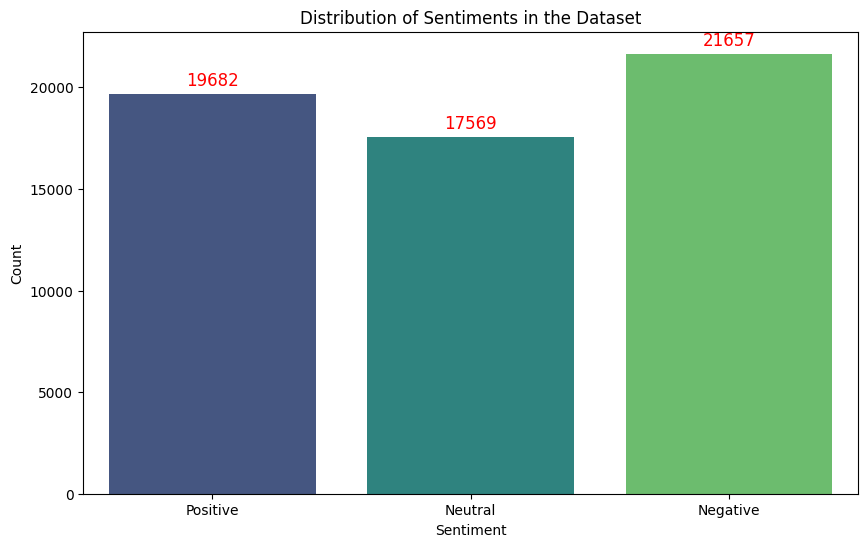

In [26]:
# Visualizing the distribution of sentiments in the dataset

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize = (10,6))
plt.title('Distribution of Sentiments in the Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
ax = sns.countplot(data = df, x = 'sentiment', palette='viridis')
for label in ax.containers:
    ax.bar_label(label, label_type='edge', fontsize=12, color='red', padding=3)
plt.show()

Text preprocessing is a crucial phase in any NLP project. In this section, I will perform a series of steps to clean and prepare the text data for classification model building, which include:

- Converting all text to lowercase

- Removing URLs and hyperlinks

- Eliminating punctuation and special characters

- Tokenizing the text into individual words

- Removing commonly used stopwords

- Applying stemming to reduce words to their root forms

In [27]:
# let's analyze the text data

df['text'][:25]

0     im getting on borderlands and i will murder yo...
1     I am coming to the borders and I will kill you...
2     im getting on borderlands and i will kill you ...
3     im coming on borderlands and i will murder you...
4     im getting on borderlands 2 and i will murder ...
5     im getting into borderlands and i can murder y...
6     So I spent a few hours making something for fu...
7     So I spent a couple of hours doing something f...
8     So I spent a few hours doing something for fun...
9     So I spent a few hours making something for fu...
10    2010 So I spent a few hours making something f...
11                                                  was
12    Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...
13    Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...
14    Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM...
15    Rock-Hard La Vita, RARE BUT POWERFUL, HANDSOME...
16    Live Rock - Hard music La la Varlope, RARE & t...
17    I-Hard like me, RARE LONDON DE, HANDSOME 2

In [28]:
import re
import string

In [29]:
def preprocess_text(text):
    
    text = text.lower() # lowering the text
    
    text = re.sub(r'https?://\S+||www.\S+', '', text)   # removing URLs
    
    text = re.sub(r'[@#]\s?\w+', '', text)  # removing mentions and hashtags
    
    text = re.sub(r'[^A-Za-z\s]', '', text)  # removing special characters and numbers
    
    text = re.sub(r'\s+', ' ', text).strip()  # removing leading and trailing spaces
    
    text = text.translate(str.maketrans('', '', string.punctuation))  # removing punctuation
    
    
    return text

In [30]:
text = 'ram is a good www.youtube.com/ @ananr 456   #dk tfg'
text = preprocess_text(text)

In [31]:
text

'ram is a good tfg'

In [32]:
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [33]:
df.head()

,tweet_id,sentiment,text,cleaned_text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


In [34]:
df['cleaned_text'][80:100]

80                                         fick yessssss
81                                       fuck yessssssss
82                                    fuck yessssssssunk
83                                     a fuck yessssssss
84                                              fuck you
85     i hate that this easy mayhem modifier event on...
86     i hate that this simple chaos modifier event o...
87     i hate that this easy mayhem modifier event on...
88     i hate saying this easy day event on mayhem wo...
89     i hate thinking that this easy mayhem modifier...
90     i hate that this easy horrible modifier event ...
91     grounded almost looked pretty cool even despit...
92     grounded looked cool despite the borderline un...
93     grosskreutz looked pretty cool even despite th...
94     grounded almost looked pretty cool here despit...
95     deep grounded almost looked pretty cool even d...
96     grounded almost was pretty cool even despite t...
103    how do i submit a compla

In [36]:
# Dry run: check it does not break anything

!pip install emoji --dry-run

Would install emoji-2.15.0


In [37]:
!pip install emoji

  Using cached emoji-2.15.0-py3-none-any.whl.metadata (5.7 kB)
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   --------------------------------- ----- 524.3/608.4 kB 16.4 MB/s eta 0:00:01
   ---------------------------------------- 608.4/608.4 kB 11.2 MB/s  0:00:00


In [38]:
# Let's handle emojis

import emoji

def handle_emojis(text):
    return emoji.demojize(text)

In [39]:
text = 'I love Python! 😍'
text = handle_emojis(text)
text

'I love Python! :smiling_face_with_heart-eyes:'

In [40]:
df['cleaned_text'] = df['cleaned_text'].apply(handle_emojis)
df.head()

,tweet_id,sentiment,text,cleaned_text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


In [41]:
df.tail()

,tweet_id,sentiment,text,cleaned_text
71434,Battlefield,Negative,I have noticed streamers I watch who are now p...,i have noticed streamers i watch who are now p...
71435,RedDeadRedemption(RDR),Neutral,@6th__man playing red dead redemption-\n\n“Oh ...,playing red dead redemption oh shit a bear sta...
71436,LeagueOfLegends,Neutral,♥️ Suikoden 2\n1️⃣ Alex Kidd in Miracle World\...,suikoden alex kidd in miracle world persona so...
71437,HomeDepot,Positive,Thank you to Matching funds Home Depot RW paym...,thank you to matching funds home depot rw paym...
71438,CallOfDuty,Neutral,Late night stream with the boys! Come watch so...,late night stream with the boys come watch som...


In [43]:
# Let's tokenize the cleaned text

from nltk.tokenize import word_tokenize

df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)
df.head()

,tweet_id,sentiment,text,cleaned_text,tokenized_text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m..."
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will..."
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k..."
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu..."
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m..."


In [44]:
# Let's flatten the tokenized text for further processing

exploded_text = df['tokenized_text'].explode().reset_index(drop=True)
exploded_text.head(20)

0              im
1         getting
2              on
3     borderlands
4             and
5               i
6            will
7          murder
8             you
9             all
10              i
11             am
12         coming
13             to
14            the
15        borders
16            and
17              i
18           will
19           kill
Name: tokenized_text, dtype: object

In [45]:
tokent_counts = exploded_text.value_counts()

In [46]:
print(f"Total Word Count\t: {exploded_text.shape[0]}")
print(f"Vocabulary Size\t\t: {tokent_counts.shape[0]}")

Total Word Count	: 1054586
Vocabulary Size		: 30478


In [47]:
# Stop words removal
# Retaining important negations and sentiment-influencing words

def remove_stop_words(tokens):
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize
    stop_words = set(stopwords.words('english'))
    stop_words.add('im')
    
    # Retain important negations and sentiment-influencing words 
    important_words = {
        'not', 'no', 'nor', "don't", "doesn't", "didn't", "isn't", "wasn't",
        "weren't", "won't", "can't", "couldn't", "shouldn't", "wouldn't",
        "haven't", "hasn't", "hadn't", "ain", "aren't", "needn't", "shan", "mustn", "mightn", "wouldn"
    }

    # Subtract important sentiment words from the stopword set
    filtered_stopwords = stop_words - important_words 

    # Filter out the stopwords from the token list
    filtered = [t for t in tokens if t not in filtered_stopwords]

    return filtered


In [48]:
df['filtered_tokens'] = df['tokenized_text'].apply(remove_stop_words)
df.head()

,tweet_id,sentiment,text,cleaned_text,tokenized_text,filtered_tokens
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]"
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]"
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[getting, borderlands, kill]"
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[coming, borderlands, murder]"
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]"


In [49]:
print('Original Token\n','-'*25,'\n',df['tokenized_text'][0])
print('-'*80)
print('Filtered Token\n','-'*25,'\n',df['filtered_tokens'][0])

Original Token
 ------------------------- 
 ['im', 'getting', 'on', 'borderlands', 'and', 'i', 'will', 'murder', 'you', 'all']
--------------------------------------------------------------------------------
Filtered Token
 ------------------------- 
 ['getting', 'borderlands', 'murder']


In [50]:
# Let's apply lemmatization to the filtered tokens

from nltk.stem import WordNetLemmatizer

def lemmatize_tokens(tokens):
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

In [51]:
df['lemmatized_tokens'] = df['filtered_tokens'].apply(lemmatize_tokens)
df.head()

,tweet_id,sentiment,text,cleaned_text,tokenized_text,filtered_tokens,lemmatized_tokens
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]","[getting, borderland, murder]"
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]","[coming, border, kill]"
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[getting, borderlands, kill]","[getting, borderland, kill]"
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[coming, borderlands, murder]","[coming, borderland, murder]"
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]","[getting, borderland, murder]"


In [52]:
print('Filtered Token\n','-'*25,'\n',df['filtered_tokens'][0])
print('-'*25)
print('Lemmatised Token\n','-'*25,'\n',df['lemmatized_tokens'][0])

Filtered Token
 ------------------------- 
 ['getting', 'borderlands', 'murder']
-------------------------
Lemmatised Token
 ------------------------- 
 ['getting', 'borderland', 'murder']


In [53]:
print('Filtered Token\n','-'*25,'\n',df['filtered_tokens'][10])
print('-'*80)
print('Lemmatised Token\n','-'*25,'\n',df['lemmatized_tokens'][10])

Filtered Token
 ------------------------- 
 ['spent', 'hours', 'making', 'something', 'fun', 'dont', 'know', 'huge', 'rhandlerr', 'fan', 'maya', 'one', 'favorite', 'characters', 'decided', 'make', 'wallpaper', 'pc', 'original', 'image', 'versus', 'creation', 'made', 'enjoy', 'pictwittercommlsiwfjg']
--------------------------------------------------------------------------------
Lemmatised Token
 ------------------------- 
 ['spent', 'hour', 'making', 'something', 'fun', 'dont', 'know', 'huge', 'rhandlerr', 'fan', 'maya', 'one', 'favorite', 'character', 'decided', 'make', 'wallpaper', 'pc', 'original', 'image', 'versus', 'creation', 'made', 'enjoy', 'pictwittercommlsiwfjg']


#### **Feature Extraction**

In Natural Language Processing (NLP), feature extraction or engineering methods are techniques used to convert human language or text into a format that machines can understand and process.

I'm going to use **Word2Vec CBOW**, It converts words into dense, real-valued vectors in a high-dimensional space, such that semantically similar words are closer together in that space.

In [54]:
# Prepare corpus as list of token lists
corpus = df['lemmatized_tokens'].tolist()
corpus[:5]

[['getting', 'borderland', 'murder'],
 ['coming', 'border', 'kill'],
 ['getting', 'borderland', 'kill'],
 ['coming', 'borderland', 'murder'],
 ['getting', 'borderland', 'murder']]

In [56]:
# Train Word2Vec: took 10 sec

import gensim
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=corpus,   # text data
    vector_size = 150,     # output vector dimensionality
    window = 8,
    min_count = 3,       # Minimum frequency to include word
    sg=0,              # Skip-gram (1) or CBOW (0)
    epochs=10,
    seed=42
)

In [57]:
w2v_model.save('tweet_w2v_model.model')

In [58]:
# Get vector for a word
print(w2v_model.wv['great'],'\n\n')

# Find similar words
print(w2v_model.wv.most_similar('great'))

[ 0.711681    1.220556   -1.1213856   1.4146227  -0.02884232  2.2639508
 -1.0263016   2.4505775   0.06007062  1.7007892   0.39670658 -0.24293137
 -0.7698163   2.0203125  -1.0800687   0.92438143  0.6153041   1.1096199
  0.20337501 -2.8267813   0.618123   -1.6166725  -0.72355825  1.0893155
  0.04208064  1.62155    -1.0553683  -0.507662   -2.4606793  -0.69389343
 -2.2226312  -0.67002743  0.4022208  -1.2844661   1.333962   -0.9382212
  1.587357   -1.6380692  -1.6990955  -0.37033817  0.6259393  -2.2110395
  0.50046515 -0.61433035  2.1066563  -0.5153082   2.1841114  -0.9071712
 -2.672268    0.27988148 -0.7142212   1.3605031  -2.150405   -0.1491247
 -0.56936353  0.8129212  -1.5098835  -3.4697073  -0.50454974  0.9101157
 -1.7803502  -3.1460838  -1.262318   -0.68816036  0.11770047 -0.22585428
 -0.1445835   1.878088   -2.5160782   0.12714905 -0.60010815 -0.40533638
  1.3925328   0.43275154 -2.7786975   2.0908332  -1.4819602   1.301537
 -0.95918965  0.05046501 -0.63156766  2.050104   -0.04771129 

In [59]:
print(w2v_model.vector_size)

150


1. Here, you have per-word vector but the classifier models need the per-tweet(sentence) vectors.
2. Task is to Convert Token Vectors → Tweet Vectors

In [60]:
def get_avg_vector(tokens):
    
    word_vectors = []
    
    for token in tokens:
        if token in w2v_model.wv:
            word_vectors.append(w2v_model.wv[token])
            
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(w2v_model.vector_size)
    

# Convert Token Vectors → Tweet Vectors
df['tweet_vector'] = df['lemmatized_tokens'].apply(get_avg_vector)
df.head()

,tweet_id,sentiment,text,cleaned_text,tokenized_text,filtered_tokens,lemmatized_tokens,tweet_vector
0,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]","[getting, borderland, murder]","[-0.63361573, 0.51678985, -0.53368795, -1.5575..."
1,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,"[i, am, coming, to, the, borders, and, i, will...","[coming, borders, kill]","[coming, border, kill]","[0.48598775, 0.056497116, 0.2208399, -0.351101..."
2,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,"[im, getting, on, borderlands, and, i, will, k...","[getting, borderlands, kill]","[getting, borderland, kill]","[-0.40214887, 0.26756015, -0.48477307, -1.2606..."
3,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,"[im, coming, on, borderlands, and, i, will, mu...","[coming, borderlands, murder]","[coming, borderland, murder]","[-0.47023535, 0.75909585, -0.60649925, -1.3254..."
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,"[im, getting, on, borderlands, and, i, will, m...","[getting, borderlands, murder]","[getting, borderland, murder]","[-0.63361573, 0.51678985, -0.53368795, -1.5575..."


In [61]:
X = np.vstack(df['tweet_vector'].values)

In [62]:
X

array([[-0.63361573,  0.51678985, -0.53368795, ..., -0.10512903,
        -0.04838017,  1.27572906],
       [ 0.48598775,  0.05649712,  0.2208399 , ..., -0.06146735,
         0.3064895 ,  0.86510354],
       [-0.40214887,  0.26756015, -0.48477307, ..., -0.05581185,
         0.22747165,  1.51967919],
       ...,
       [ 0.36289081, -0.04381536,  0.22695537, ...,  0.14899759,
         0.59362286, -0.32678762],
       [ 0.00329817,  0.0413159 ,  0.40018788, ...,  0.71389681,
        -0.10107776, -0.40188053],
       [ 0.06069742,  0.15331791,  0.06762829, ..., -0.01612008,
         0.51119727,  1.10546148]])

In [63]:
y = df['sentiment'].values

In [64]:
y

array(['Positive', 'Positive', 'Positive', ..., 'Neutral', 'Positive',
       'Neutral'], dtype=object)

In [65]:
# Encode the sentiment labels to numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [66]:
y

array([2, 2, 2, ..., 1, 2, 1])

In [67]:
# Let's build the model

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((47126, 150), (11782, 150), (47126,), (11782,))

In [88]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

model_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [89]:
model_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [91]:
# Predicting on the test set
y_pred = model_clf.predict(X_test)

In [93]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82      4337
     Neutral       0.83      0.71      0.76      3482
    Positive       0.79      0.82      0.80      3963

    accuracy                           0.80     11782
   macro avg       0.80      0.79      0.79     11782
weighted avg       0.80      0.80      0.80     11782



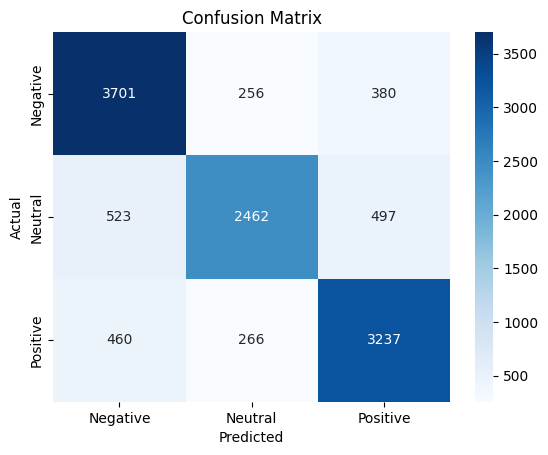

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [95]:
sample_text = "I really love this new update!"

In [96]:
text = preprocess_text(sample_text)

In [97]:
text

'i really love this new update'

In [98]:
tokens = word_tokenize(text)
tokens

['i', 'really', 'love', 'this', 'new', 'update']

In [99]:
cleaned_tokens = remove_stop_words(tokens)

In [100]:
cleaned_tokens

['really', 'love', 'new', 'update']

In [105]:
import numpy as np

def vectorize(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)  # handle unseen or empty words
    return np.mean(vectors, axis=0)

sample_vector = vectorize(cleaned_tokens, w2v_model).reshape(1, -1)


In [106]:
sample_vector

array([[-0.0283747 ,  0.5109316 ,  0.8126373 , -0.38550675, -0.19207859,
        -0.08117881, -0.06242085, -0.00691804,  0.5808459 ,  0.15473488,
         0.7357825 , -0.14370537,  0.6268713 ,  1.9976068 , -1.2272025 ,
        -1.09105   ,  0.08336835,  0.36659354, -0.3968835 ,  0.525035  ,
         0.23538533, -0.8420789 , -0.3365275 , -0.6364416 ,  0.03484542,
         0.7907261 , -1.0353045 ,  1.5235505 , -1.2479199 ,  0.6577213 ,
        -0.62852633, -0.09441226,  0.40789667, -0.3322345 , -0.22115858,
         0.4783299 , -0.01066926,  0.15094976, -0.6399213 , -0.6381737 ,
         0.7476881 ,  0.38731387,  1.6506102 , -0.5277594 ,  1.0703781 ,
         0.7486515 ,  0.28317493, -0.18845892, -0.5046532 ,  0.59619313,
        -0.3458429 ,  0.05247592,  0.5279087 , -0.14624645,  1.217703  ,
         0.07034859, -1.3506073 ,  0.04895842, -0.17608361,  0.06708065,
         0.48886275,  1.2739432 , -0.85339844,  0.19952756, -1.1629801 ,
        -0.48002416, -1.2043718 , -0.0236266 , -1.1

In [107]:
predicted_class = model_clf.predict(sample_vector)
predicted_label = le.inverse_transform(predicted_class)

print(f"Predicted sentiment: {predicted_label[0]}")

Predicted sentiment: Positive


#### Deep Learning - ANN Model for Text Classification Task

In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [111]:
ann_model = Sequential()
ann_model.add(Dense(128, activation = 'relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dropout(0.4))
ann_model.add(Dense(64, activation = 'relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(32, activation = 'relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(len(le.classes_), activation='softmax'))
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,763 (116.26 KB)

 Trainable params: 29,763 (116.26 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
history = ann_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5443 - loss: 0.9529 - val_accuracy: 0.6384 - val_loss: 0.8326
Epoch 2/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6126 - loss: 0.8719 - val_accuracy: 0.6438 - val_loss: 0.8163
Epoch 3/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6221 - loss: 0.8518 - val_accuracy: 0.6471 - val_loss: 0.8130
Epoch 4/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6307 - loss: 0.8337 - val_accuracy: 0.6510 - val_loss: 0.7908
Epoch 5/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6358 - loss: 0.8233 - val_accuracy: 0.6531 - val_loss: 0.7854
Epoch 6/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6434 - loss: 0.8120 - val_accuracy: 0.6533 - val_loss: 0.7808
Epoch 7/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6444 - loss: 0.8026 - val_accuracy: 0.6541 - val_loss: 0.7702
Epoch 8/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6526 - loss: 0.7922 - 

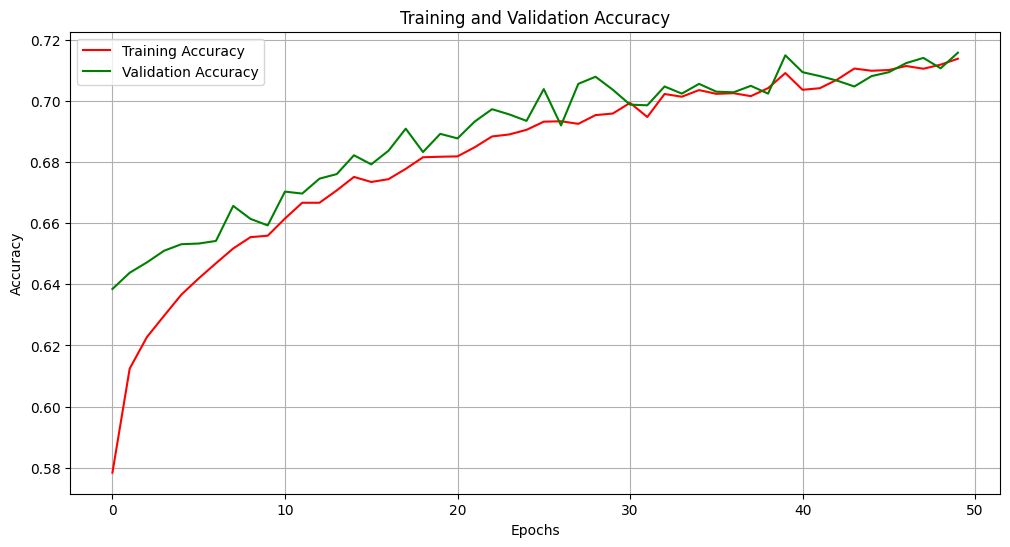

In [114]:
#Let's visualize the training history

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color = 'green')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


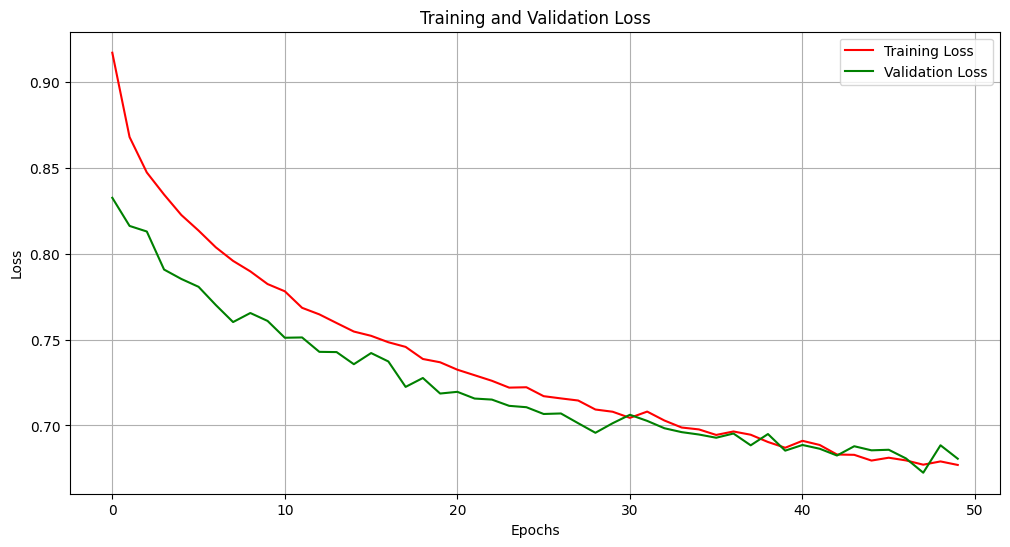

In [115]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color = 'green')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [123]:
# Let's see how the model performs - Two values will be returned. 
# Loss (a number which represents our error, lower values are better), 
# and accuracy.

loss, accuracy = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 0.7061
Test Loss: 0.6966


Test Accuracy: 0.7061 (70.6%): This means your model correctly predicted the sentiment for about 71 out of every 100 tweets in the unseen test data. While this is significantly better than random guessing (which would be ~33% for three classes), it also means the model is incorrect nearly 30% of the time.

Test Loss: 0.6966: Loss represents the model's error. A lower value is better. A value of ~0.7 indicates that the model's predictions are still quite far from the true labels, aligning with the ~71% accuracy.

In [125]:
# Get predictions
y_pred_ann_prob = ann_model.predict(X_test)
y_pred_ann = y_pred_ann_prob.argmax(axis=1)

369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [126]:
y_pred_ann

array([0, 2, 2, ..., 2, 2, 0], dtype=int64)

In [127]:
# Print the classification report
print(classification_report(y_test, y_pred_ann, target_names=le.classes_))

              precision    recall  f1-score   support

    Negative       0.73      0.77      0.75      4337
     Neutral       0.69      0.59      0.64      3482
    Positive       0.69      0.75      0.72      3963

    accuracy                           0.71     11782
   macro avg       0.70      0.70      0.70     11782
weighted avg       0.71      0.71      0.70     11782



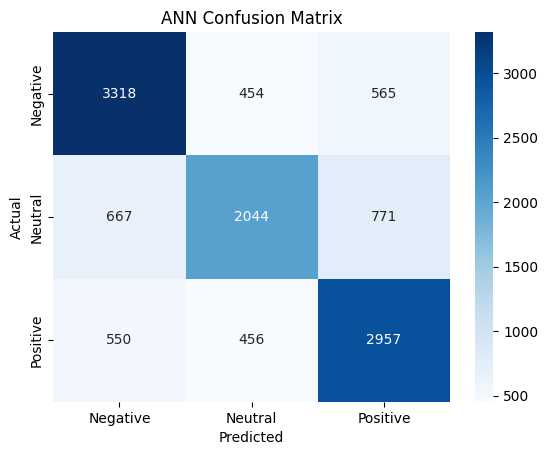

In [128]:
# Plot the confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()

In [130]:
# Use the same sample text and preprocessing as before
sample_text_ann = "This new update is fantastic, I love it!"
processed_text_ann = preprocess_text(sample_text_ann)
tokens_ann = word_tokenize(processed_text_ann)
cleaned_tokens_ann = remove_stop_words(tokens_ann)
vector_ann = vectorize(cleaned_tokens_ann, w2v_model).reshape(1, -1)

# Predict with the ANN
predicted_class_ann_prob = ann_model.predict(vector_ann)
predicted_class_ann = predicted_class_ann_prob.argmax(axis=1)
predicted_label_ann = le.inverse_transform(predicted_class_ann)

print(f"Predicted sentiment (ANN): {predicted_label_ann[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted sentiment (ANN): Positive


**Observations:**

Traditional Artificial Neural Networks (ANNs) (and most Machine Learning (ML) models) struggle with sequential data because they treat each input as independent, failing to capture the inherent relationships and dependencies between data points in a sequence. This limitation makes them less effective for tasks like natural language processing, time series analysis, and other applications where the order of information is crucial

**Lack of Memory:**
ANNs, especially feedforward networks, process each input independently. They don't have a built-in mechanism to remember past inputs or maintain a "state" that reflects the sequence's history. 

**Limited Context:**
When processing a sequence, a standard ANN might see a word in a sentence without considering the surrounding words, leading to a loss of context and potentially incorrect interpretations. 

**Difficulty with Variable Length Sequences:**
Traditional ANNs can struggle with sequences of varying lengths. They often require padding or truncation to fit the input data into a fixed-size format, which can distort the data and reduce performance. 

**To address these issues with sequencial data, Recurrent Neural Networks (RNNs) are better**
